# Part 5 : LSTM Autoencoder

## This notebook implements a deep learning approach using LSTM Autoencoders:
1. Load and preprocess data (same as Isolation Forest)
2. Create sequence data for LSTM
3. Build LSTM Autoencoder architecture
4. Train with reconstruction loss
5. Detect anomalies using reconstruction error
6. Compare with Isolation Forest and Z-score baseline
7. Visualize and interpret results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import STL
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
np.random.seed(42)

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)

TensorFlow version: 2.20.0


## Load Dataset (Same as Isolation Forest)

In [3]:
def best_dataset(data_dir='C:/Users/owen/projects/time-series-anomaly-detection/data/raw/A1Benchmark'):
    all_files = glob.glob(f'{data_dir}/*.csv')
    if len(all_files) == 0:
        raise FileNotFoundError(f"Files not found in {data_dir}")
    print(f"scanning {len(all_files)} files...")
    best_file = None
    best_anomaly_count = 0
    file_info = []
    
    for file in all_files:
        try:
            df_temp = pd.read_csv(file)
            if 'is_anomaly' not in df_temp.columns or 'value' not in df_temp.columns:
                continue
            anomaly_count = df_temp['is_anomaly'].sum()
            file_info.append({'filename': file.split('/')[-1],'samples': len(df_temp),
                              'anomalies': int(anomaly_count),'anomaly_rate': f"{anomaly_count/len(df_temp)*100:.2f}%"})
            if anomaly_count > best_anomaly_count:
                best_anomaly_count = anomaly_count
                best_file = file
        except:
            continue
            
    if file_info:
        info_df = pd.DataFrame(file_info).sort_values('anomalies', ascending=False)
        print("\nDatasets sorted by num of anomalies:")
        print(info_df.to_string(index=False))
    if best_file is None:
        raise ValueError("No suitable dataset.")
    
    df = pd.read_csv(best_file)
    print(f"\nSELECTED DATASET: {best_file.split('/')[-1]}")
    print(f"Total samples: {len(df)}")
    print(f"Total anomalies: {df['is_anomaly'].sum()}")
    print(f"Anomaly rate: {df['is_anomaly'].sum()/len(df)*100:.2f}%")
    return df
df = best_dataset()
df.head(10)

scanning 67 files...

Datasets sorted by num of anomalies:
               filename  samples  anomalies anomaly_rate
A1Benchmark\real_17.csv     1424        227       15.94%
A1Benchmark\real_19.csv     1424        227       15.94%
A1Benchmark\real_46.csv     1441        109        7.56%
A1Benchmark\real_28.csv     1441         82        5.69%
A1Benchmark\real_40.csv     1427         80        5.61%
A1Benchmark\real_26.csv     1435         75        5.23%
A1Benchmark\real_22.csv     1420         63        4.44%
 A1Benchmark\real_7.csv     1423         61        4.29%
A1Benchmark\real_32.csv     1427         47        3.29%
A1Benchmark\real_42.csv     1440         44        3.06%
A1Benchmark\real_25.csv     1435         43        3.00%
A1Benchmark\real_58.csv     1435         43        3.00%
A1Benchmark\real_37.csv     1434         34        2.37%
A1Benchmark\real_20.csv     1422         33        2.32%
A1Benchmark\real_43.csv     1440         32        2.22%
A1Benchmark\real_31.csv     1

,timestamp,value,is_anomaly
0,1,0,0
1,2,61,0
2,3,1495,0
3,4,1208,0
4,5,1347,0
5,6,1483,0
6,7,776,0
7,8,769,0
8,9,882,0
9,10,1249,0


## Data Preprocessing for LSTM
LSTM Autoencoders require:
- Normalized data (0-1 range for better convergence)
- Sequence format (sliding windows)
- 3D shape: (samples, timesteps, features)

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
df['value_normalized'] = scaler.fit_transform(df[['value']])
stl = STL(df['value_normalized'], seasonal=13, period=24)
result = stl.fit()
df['trend'] = result.trend
df['seasonal'] = result.seasonal
df['residual'] = result.resid
print(f"Columns: {df.columns.tolist()}")

Columns: ['timestamp', 'value', 'is_anomaly', 'value_normalized', 'trend', 'seasonal', 'residual']


##  Create Sequences for LSTM
Convert time series into sequences of fixed length (timesteps).

In [5]:
def create_sequences(data,labels,timesteps=10,features_use=None):
    if features_use is None:
        features_use = ['value_normalized', 'trend', 'seasonal', 'residual']
    data_values = data[features_use].values
    X = []
    y = []
    for i in range(len(data_values) - timesteps):
        X.append(data_values[i:i + timesteps])
        y.append(labels[i + timesteps])
    return np.array(X), np.array(y)

In [6]:
TIMESTEPS = 10 
features = {'value_only': ['value_normalized'],
            'with_stl': ['value_normalized', 'trend', 'seasonal', 'residual'],
            'residual_only': ['residual']}
feature = features['with_stl']
X_seq, y_seq = create_sequences(df, df['is_anomaly'].values, timesteps=TIMESTEPS,features_use=feature)
print(f"\nSequences:")
print(f"X shape: {X_seq.shape}")
print(f"y shape: {y_seq.shape}")
print(f"Anomalies in sequences: {y_seq.sum()}")


Sequences:
X shape: (1414, 10, 4)
y shape: (1414,)
Anomalies in sequences: 227


## Train/Test Split

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X_seq, y_seq,test_size=0.3,stratify=y_seq,random_state=42)
print(f"Train sequences: {len(X_train)} with {y_train.sum()} anomalies")
print(f"Test sequences:  {len(X_test)} with {y_test.sum()} anomalies")
print(f"Input shape each sample: {X_train.shape[1:]}")

Train sequences: 989 with 159 anomalies
Test sequences:  425 with 68 anomalies
Input shape each sample: (10, 4)


# Build LSTM Autoencoder Architecture
Autoencoder Structure:
- Encoder: Compresses sequences into latent representation
- Decoder: Reconstructs original sequences from latent space
- Anomaly Detection: High reconstruction error = anomaly

### The architecture below is not the final architecure. The final version will be at **final_lstm* after hyperparameter tuning.

In [8]:
def lstm_scratch(timesteps, n_features, latent_dim=8):
    inputs = layers.Input(shape=(timesteps, n_features))
    #Encoder
    # layer 1
    encode = layers.LSTM(32,activation='relu',return_sequences=True)(inputs)
    encode = layers.Dropout(0.2)(encode)
    # layer 2
    encode = layers.LSTM(16,activation='relu',return_sequences=True)(encode)
    encode = layers.Dropout(0.2)(encode)
    # layer 3
    encode = layers.LSTM(latent_dim,activation='relu',return_sequences=False)(encode)
    #Decoder
    decode = layers.RepeatVector(timesteps)(encode)
    # layer 1
    decode = layers.LSTM(latent_dim,activation='relu',return_sequences=True)(decode)
    decode = layers.Dropout(0.2)(decode)
    # layer 2
    decode = layers.LSTM(16,activation='relu',return_sequences=True)(decode)
    decode = layers.Dropout(0.2)(decode)
    # layer 3
    decode = layers.LSTM(32,activation='relu',return_sequences=True)(decode)
    # Output layer
    outputs = layers.TimeDistributed(layers.Dense(n_features))(decode)
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),loss='mse',metrics=['mae'])
    return model

In [9]:
timesteps = X_train.shape[1]
n_features = X_train.shape[2]
model = lstm_scratch(timesteps=timesteps,n_features=n_features,latent_dim=8)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 32)         │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 16)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 10, 16)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 10, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 4)          │           132 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,220 (67.27 KB)

 Trainable params: 17,220 (67.27 KB)

 Non-trainable params: 0 (0.00 B)

## Hyperparameter Tuning
We'll test different combinations of:
- Sequence length (timesteps): How far back to look
- Latent dimension: Size of compressed representation
- LSTM units: Network capacity
- Learning rate: Training speed

In [10]:
param_grid = {'timesteps': [5,10,15],
              'latent_dim': [4,8,16],
              'lstm_units': [(16,8), (32,16), (64,32)],
              'learning_rate': [0.001,0.0005],
              'batch_size': [32,64] }
for param, values in param_grid.items():
    print(f"{param:20s}: {values}")
total_combinations = (len(param_grid['timesteps']) * 
                      len(param_grid['latent_dim']) * 
                      len(param_grid['lstm_units']) * 
                      len(param_grid['learning_rate']) * 
                      len(param_grid['batch_size']))
print(f"Total combinations is {total_combinations}")

timesteps           : [5, 10, 15]
latent_dim          : [4, 8, 16]
lstm_units          : [(16, 8), (32, 16), (64, 32)]
learning_rate       : [0.001, 0.0005]
batch_size          : [32, 64]
Total combinations is 108


In [11]:
from itertools import product
import time

def build_and_train_lstm(X_train,X_val,timesteps,n_features,latent_dim=8, lstm_units=(32, 16), 
                         learning_rate=0.001, batch_size=32,epochs=50, verbose=0):
    inputs = layers.Input(shape=(timesteps, n_features)) 
    #Encoder
    encode = layers.LSTM(lstm_units[0],activation='relu',return_sequences=True)(inputs)
    encode = layers.Dropout(0.2)(encode)
    encode = layers.LSTM(lstm_units[1],activation='relu',return_sequences=True)(encode)
    encode = layers.Dropout(0.2)(encode)
    encode = layers.LSTM(latent_dim,activation='relu',return_sequences=False)(encode)
    #Decoder
    decode = layers.RepeatVector(timesteps)(encode)
    decode = layers.LSTM(latent_dim,activation='relu',return_sequences=True)(decode)
    decode = layers.Dropout(0.2)(decode)
    decode = layers.LSTM(lstm_units[1],activation='relu',return_sequences=True)(decode)
    decode = layers.Dropout(0.2)(decode)
    decode = layers.LSTM(lstm_units[0],activation='relu',return_sequences=True)(decode)
    outputs = layers.TimeDistributed(layers.Dense(n_features))(decode)
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),loss='mse',metrics=['mae'])
    #Early stopping
    early_stopping = callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True,verbose=0)
    #Train
    train1 = model.fit(X_train, X_train,epochs=epochs,
                       batch_size=batch_size,validation_data=(X_val, X_val),
                       callbacks=[early_stopping],verbose=verbose)
    
    # Get best validation loss
    best_val_loss = min(train1.history['val_loss'])
    return {'model': model,'train': train1,'val_loss': best_val_loss,'epochs_trained': len(train1.history['loss'])}

In [12]:
import random
n_trials = 10
search_results = []
best_params = None
best_model_result = None
best_f1 = 0.0
random.seed(42)
for trial in range(n_trials):
    params = {'timesteps': random.choice(param_grid['timesteps']),
              'latent_dim': random.choice(param_grid['latent_dim']),
              'lstm_units': random.choice(param_grid['lstm_units']),
              'learning_rate': random.choice(param_grid['learning_rate']),
              'batch_size': random.choice(param_grid['batch_size'])}
    print(f"\n{trial+1}/{n_trials}:")
    print(f"Timesteps: {params['timesteps']}, Latent: {params['latent_dim']}, "
          f"LSTM: {params['lstm_units']}, LR: {params['learning_rate']}, Batch: {params['batch_size']}")
    try:
        X_seq_temp, y_seq_temp = create_sequences(df,df['is_anomaly'].values,timesteps=params['timesteps'],features_use=feature)
        X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_seq_temp, y_seq_temp, test_size=0.3,random_state=42)
        X_train_normal = X_train_temp[y_train_temp==0]
        val_size = int(0.2 * len(X_train_normal))
        X_train_model = X_train_normal
        X_val_threshold = X_train_normal
        start_time = time.time()
        result = build_and_train_lstm(X_train_model, X_val_threshold,
                                      timesteps=params['timesteps'],
                                      n_features=X_train_temp.shape[2],
                                      latent_dim=params['latent_dim'],
                                      lstm_units=params['lstm_units'],
                                      learning_rate=params['learning_rate'],
                                      batch_size=params['batch_size'],
                                      epochs=50,
                                      verbose=0)
        train_time = time.time()-start_time
        X_test_pred = result['model'].predict(X_test_temp,verbose=0)
        val_pred = result['model'].predict(X_val_threshold, verbose=0)
        val_errors = np.mean(np.square(X_val_threshold - val_pred), axis=(1, 2))
        threshold_temp = np.percentile(val_errors, 97)
        reconstruction_error_temp = np.mean(np.square(X_test_temp - X_test_pred), axis=(1, 2))
        y_pred_temp = (reconstruction_error_temp > threshold_temp).astype(int)
        #Metrics
        precision = precision_score(y_test_temp,y_pred_temp,zero_division=0)
        recall = recall_score(y_test_temp,y_pred_temp,zero_division=0)
        f1 = f1_score(y_test_temp,y_pred_temp,zero_division=0)
        trial_result = {'trial': trial + 1,
                        'timesteps': params['timesteps'],
                        'latent_dim': params['latent_dim'],
                        'lstm_units': (params['lstm_units'][0],params['lstm_units'][1]),
                        'learning_rate': params['learning_rate'],
                        'batch_size': params['batch_size'],
                        'val_loss': result['val_loss'],
                        'epochs_trained': result['epochs_trained'],
                        'train_time': train_time,
                        'precision': precision, 'recall': recall,
                        'f1': f1,'threshold': threshold_temp }
        search_results.append(trial_result)
        print(f"Val Loss:{result['val_loss']:.6f} and F1:{f1:.4f} and P:{precision:.4f} and R:{recall:.4f} and Time:{train_time:.1f}s")
        if f1 > best_f1:  
            best_f1 = f1
            best_params = params
            best_model_result = {'model': result['model'],'X_test': X_test_temp,'y_test': y_test_temp,'threshold': threshold_temp}
            print(f"New best F1-Score is {f1:.4f}")
    except Exception as e:
        print(f"Trial failed: {str(e)}")
        continue


1/10:
Timesteps: 15, Latent: 4, LSTM: (16, 8), LR: 0.0005, Batch: 32
Val Loss:0.001348 and F1:0.9272 and P:0.8750 and R:0.9859 and Time:38.6s
New best F1-Score is 0.9272

2/10:
Timesteps: 15, Latent: 16, LSTM: (32, 16), LR: 0.001, Batch: 64
Val Loss:0.001074 and F1:0.9281 and P:0.8659 and R:1.0000 and Time:25.4s
New best F1-Score is 0.9281

3/10:
Timesteps: 15, Latent: 8, LSTM: (16, 8), LR: 0.0005, Batch: 32
Val Loss:0.001115 and F1:0.9200 and P:0.8734 and R:0.9718 and Time:37.8s

4/10:
Timesteps: 5, Latent: 8, LSTM: (32, 16), LR: 0.0005, Batch: 64
Val Loss:0.001143 and F1:0.9404 and P:0.8875 and R:1.0000 and Time:18.9s
New best F1-Score is 0.9404

5/10:
Timesteps: 15, Latent: 4, LSTM: (64, 32), LR: 0.0005, Batch: 32
Val Loss:0.001063 and F1:0.9091 and P:0.8434 and R:0.9859 and Time:40.6s

6/10:
Timesteps: 10, Latent: 4, LSTM: (16, 8), LR: 0.0005, Batch: 64
Val Loss:0.002193 and F1:0.9650 and P:0.9324 and R:1.0000 and Time:22.6s
New best F1-Score is 0.9650

7/10:
Timesteps: 15, Latent

In [13]:
np.mean(y_pred_temp)

np.float64(0.18912529550827423)

In [14]:
from sklearn.metrics import roc_auc_score
roc_auc_val = roc_auc_score(y_test_temp,reconstruction_error_temp)
print(f"F1:{f1:.4f}, P:{precision:.4f}, R:{recall:.4f}, AUC:{roc_auc_val:.4f}")

F1:0.9272, P:0.8750, R:0.9859, AUC:0.9847


In [15]:
results_df = pd.DataFrame(search_results)
results_df = results_df.sort_values('f1',ascending=False)
print("Top 10 Hyperparameter combinations:")
print(results_df[['trial', 'timesteps', 'latent_dim', 'lstm_units', 'learning_rate', 'batch_size', 'f1', 'precision', 'recall']].head(10).to_string(index=False))

Top 10 Hyperparameter combinations:
 trial  timesteps  latent_dim lstm_units  learning_rate  batch_size       f1  precision   recall
     6         10           4    (16, 8)         0.0005          64 0.965035   0.932432 1.000000
     4          5           8   (32, 16)         0.0005          64 0.940397   0.887500 1.000000
     8          5          16    (16, 8)         0.0005          32 0.940397   0.887500 1.000000
     9          5          16    (16, 8)         0.0010          64 0.940397   0.887500 1.000000
     2         15          16   (32, 16)         0.0010          64 0.928105   0.865854 1.000000
     1         15           4    (16, 8)         0.0005          32 0.927152   0.875000 0.985915
    10         15           8   (32, 16)         0.0005          64 0.927152   0.875000 0.985915
     7         15           8   (64, 32)         0.0005          32 0.922078   0.855422 1.000000
     3         15           8    (16, 8)         0.0005          32 0.920000   0.873418 0.9

In [16]:
print("\nHyperparameter importance:")
for param in ['timesteps', 'latent_dim', 'learning_rate', 'batch_size']:
    grouped = results_df.groupby(param)['f1'].agg(['mean', 'std', 'count'])
    print(f"\n{param.upper()}:")
    print(grouped.to_string())
    best_value = grouped['mean'].idxmax()
    best_mean = grouped.loc[best_value, 'mean']
    print(f" Best: {best_value} with mean F1: {best_mean:.4f}")


Hyperparameter importance:

TIMESTEPS:
               mean       std  count
timesteps                           
5          0.940397  0.000000      3
10         0.965035       NaN      1
15         0.922263  0.007219      6
 Best: 10 with mean F1: 0.9650

LATENT_DIM:
                mean       std  count
latent_dim                           
4           0.933759  0.028551      3
8           0.927407  0.009167      4
16          0.936300  0.007097      3
 Best: 16 with mean F1: 0.9363

LEARNING_RATE:
                   mean       std  count
learning_rate                           
0.0005         0.931413  0.017087      8
0.0010         0.934251  0.008692      2
 Best: 0.001 with mean F1: 0.9343

BATCH_SIZE:
                mean       std  count
batch_size                           
32          0.923744  0.011407      5
64          0.940217  0.015276      5
 Best: 64 with mean F1: 0.9402


## Build, Train and Test Final Model
**Important** : We train on NORMAL data only!
- The model learns to reconstruct normal patterns
- Anomalies will have high reconstruction error

In [17]:
def final_lstm(timesteps, n_features, latent_dim=8, lstm_units=(32,16),learning_rate=0.001,batch_size=32):
    inputs = layers.Input(shape=(timesteps,n_features))
    #Encoder
    encode = layers.LSTM(lstm_units[0],activation='relu', return_sequences=True)(inputs)
    encode = layers.BatchNormalization()(encode)  # add batch norm
    encode = layers.Dropout(0.3)(encode)  # increase dropout
    encode = layers.LSTM(lstm_units[1], activation='relu', return_sequences=True)(encode)
    encode = layers.BatchNormalization()(encode)
    encode = layers.Dropout(0.3)(encode)
    encode = layers.LSTM(latent_dim, activation='relu', return_sequences=False)(encode)
    #Decoder
    decode = layers.RepeatVector(timesteps)(encode)
    decode = layers.LSTM(latent_dim, activation='relu', return_sequences=True)(decode)
    decode = layers.BatchNormalization()(decode)
    decode = layers.Dropout(0.3)(decode)
    decode = layers.LSTM(lstm_units[1], activation='relu', return_sequences=True)(decode)
    decode = layers.BatchNormalization()(decode)
    decode = layers.Dropout(0.3)(decode)
    decode = layers.LSTM(lstm_units[0], activation='relu', return_sequences=True)(decode)
    outputs = layers.TimeDistributed(layers.Dense(n_features))(decode)
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),loss='mse',metrics=['mae'])
    return model

In [18]:
X_seq_10, y_seq_10 = create_sequences(df,df['is_anomaly'].values,timesteps=10,features_use=feature)
X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(X_seq_10, y_seq_10, test_size=0.3, stratify=y_seq_10, random_state=42)
X_train_normal_10 = X_train_10[y_train_10==0]
train_size = int(0.8*len(X_train_normal_10))
X_train_final = X_train_normal_10[:train_size]
X_val_10 = X_train_normal_10[train_size:]

In [19]:
model_final= final_lstm(timesteps=10,n_features=4,latent_dim=4,lstm_units=(16,8),learning_rate=0.0005,batch_size=64)
model_final.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 10, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_66 (LSTM)                  │ (None, 10, 16)         │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_67 (LSTM)                  │ (None, 10, 8)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 8)          │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_68 (LSTM)                  │ (None, 4)              │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_11 (RepeatVector) │ (None, 10, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_69 (LSTM)                  │ (None, 10, 4)          │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 4)          │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 10, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_70 (LSTM)                  │ (None, 10, 8)          │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 8)          │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_71 (LSTM)                  │ (None, 10, 16)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 10, 4)          │            68 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,724 (18.45 KB)

 Trainable params: 4,652 (18.17 KB)

 Non-trainable params: 72 (288.00 B)

In [20]:
# More epochs, model needs time to learn
early_stopping = callbacks.EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True,verbose=1,min_delta=1e-6,mode='min')
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=7, min_lr=1e-6,verbose=1,mode='min')
checkpoint = callbacks.ModelCheckpoint('models/lstm_best_model.keras',monitor='val_loss',save_best_only=True,verbose=1)
train_final = model_final.fit(X_train_final, X_train_final,epochs=200,batch_size=64,
                              validation_data=(X_val_10,X_val_10),callbacks=[early_stopping, reduce_lr, checkpoint],verbose=1)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1718 - mae: 0.2048
Epoch 1: val_loss improved from None to 0.00439, saving model to models/lstm_best_model.keras

Epoch 1: finished saving model to models/lstm_best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - loss: 0.1831 - mae: 0.2016 - val_loss: 0.0044 - val_mae: 0.0442 - learning_rate: 5.0000e-04
Epoch 2/200
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1343 - mae: 0.1827
Epoch 2: val_loss improved from 0.00439 to 0.00411, saving model to models/lstm_best_model.keras

Epoch 2: finished saving model to models/lstm_best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1365 - mae: 0.1798 - val_loss: 0.0041 - val_mae: 0.0424 - learning_rate: 5.0000e-04
Epoch 3/200
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1114 - mae: 0.1626
Epoch 3: val_loss improved from 0.00411 to 0.00388, saving model to models/lstm_best_model.keras

Epoch 3: finished saving model to models/lstm_best_model.keras
11/11 ━━

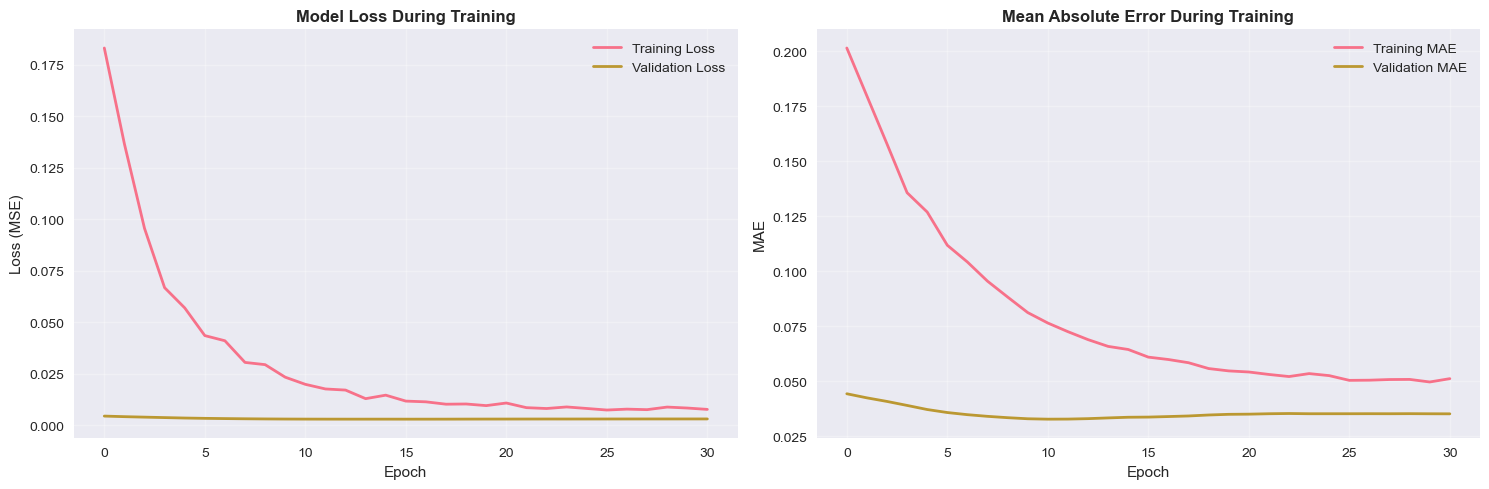

In [28]:
fig,axes = plt.subplots(1,2,figsize=(15,5))
# Loss
axes[0].plot(train_final.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(train_final.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Model Loss During Training',fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# MAE
axes[1].plot(train_final.history['mae'],label='Training MAE',linewidth=2)
axes[1].plot(train_final.history['val_mae'],label='Validation MAE',linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error During Training',fontweight='bold')
axes[1].legend()
axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

## Calculate Reconstruction Error
Anomalies should have higher reconstruction error than normal data.

In [21]:
X_test_pred = model_final.predict(X_test_10, verbose=0)
reconstruction_error = np.mean(np.square(X_test - X_test_pred), axis=(1, 2))
print("Reconstruction Error stats:")
print(f"Mean IS {reconstruction_error.mean():.6f}")
print(f"Std IS {reconstruction_error.std():.6f}")
print(f"Min IS {reconstruction_error.min():.6f}")
print(f"Max IS {reconstruction_error.max():.6f}")
print(f"Median IS {np.median(reconstruction_error):.6f}")

Reconstruction Error stats:
Mean IS 0.015570
Std IS 0.036351
Min IS 0.000398
Max IS 0.217639
Median IS 0.001469


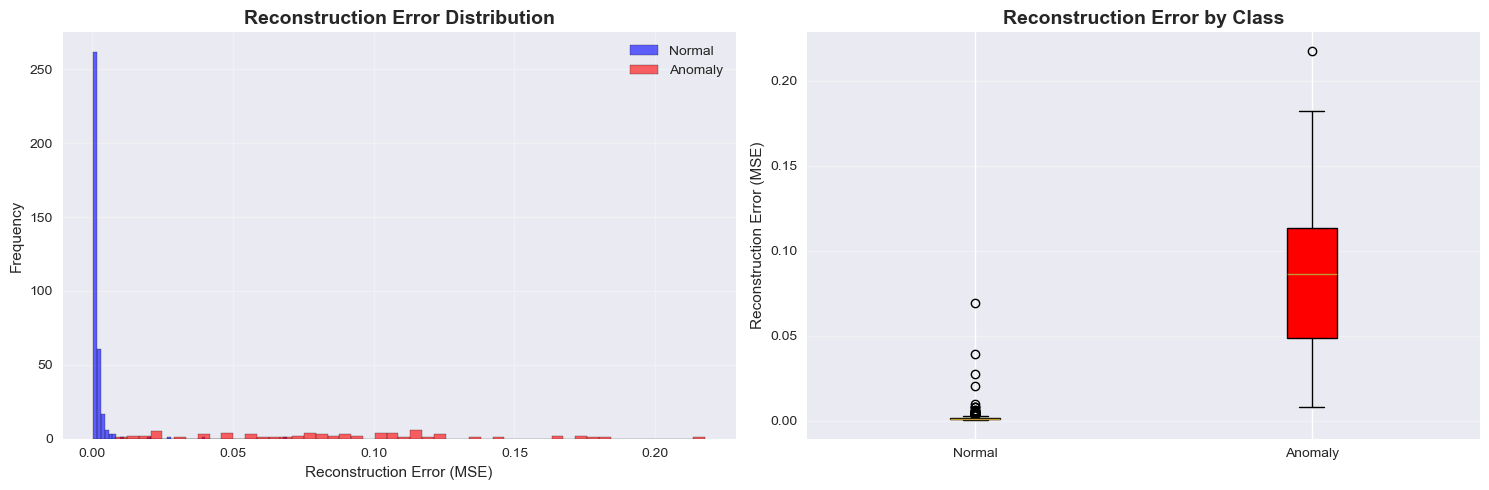


Reconstruction Error by Class:
Normal = Mean: 0.002074, Std: 0.004586
Anomaly = Mean: 0.086425, Std: 0.046600

Separation: 41.67x higher error for anomalies


In [22]:
fig,axes = plt.subplots(1,2,figsize=(15,5))
ax1 = axes[0]
normal_errors = reconstruction_error[y_test==0]
anomaly_errors = reconstruction_error[y_test==1]
ax1.hist(normal_errors,bins=50,alpha=0.6,label='Normal',color='blue',edgecolor='black')
ax1.hist(anomaly_errors,bins=50,alpha=0.6,label='Anomaly',color='red',edgecolor='black')
ax1.set_xlabel('Reconstruction Error (MSE)')
ax1.set_ylabel('Frequency')
ax1.set_title('Reconstruction Error Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
#Boxplot
ax2 = axes[1]
data_to_plot = [normal_errors, anomaly_errors]
bp = ax2.boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('red')
ax2.set_ylabel('Reconstruction Error (MSE)')
ax2.set_title('Reconstruction Error by Class', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("\nReconstruction Error by Class:")
print(f"Normal = Mean: {normal_errors.mean():.6f}, Std: {normal_errors.std():.6f}")
print(f"Anomaly = Mean: {anomaly_errors.mean():.6f}, Std: {anomaly_errors.std():.6f}")
print(f"\nSeparation: {(anomaly_errors.mean() / normal_errors.mean()):.2f}x higher error for anomalies")

## Threshold Selection and Prediction
Find optimal threshold for classifying anomalies based on reconstruction error.

In [23]:
finding_threshold = {'mean + 2*std': normal_errors.mean() + 2 * normal_errors.std(),
                        'mean + 3*std': normal_errors.mean() + 3 * normal_errors.std(),
                        '95th percentile': np.percentile(normal_errors, 95),
                        '99th percentile': np.percentile(normal_errors, 99),
                        'median + 2*MAD': np.median(normal_errors) + 2 * np.median(np.abs(normal_errors - np.median(normal_errors)))}
best_f1 = 0
best_threshold = None
best_strategy = None
threshold_results = []
for strategy, threshold in finding_threshold.items():
    y_pred = (reconstruction_error > threshold).astype(int)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    threshold_results.append({'strategy': strategy,'threshold': threshold,
                              'precision': precision,'recall': recall,'f1': f1})
    print(f"{strategy:20s} have threshold: {threshold:.6f} , P: {precision:.4f} , R: {recall:.4f} , F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_strategy = strategy
print(f"\nBest way: {best_strategy}")
print(f"Best threshold: {best_threshold:.6f}")
print(f"Best F1-Score: {best_f1:.4f}")
y_pred_final = (reconstruction_error > best_threshold).astype(int)

mean + 2*std         have threshold: 0.011246 , P: 0.9437 , R: 0.9853 , F1: 0.9640
mean + 3*std         have threshold: 0.015832 , P: 0.9420 , R: 0.9559 , F1: 0.9489
95th percentile      have threshold: 0.004431 , P: 0.7907 , R: 1.0000 , F1: 0.8831
99th percentile      have threshold: 0.014689 , P: 0.9420 , R: 0.9559 , F1: 0.9489
median + 2*MAD       have threshold: 0.002158 , P: 0.4823 , R: 1.0000 , F1: 0.6507

Best way: mean + 2*std
Best threshold: 0.011246
Best F1-Score: 0.9640


## Model Evaluation and Comparison

In [24]:
print("LSTM AUTOENCODER PERFORMANCE ON TEST SET")
print(classification_report(y_test, y_pred_final,target_names=['Normal', 'Anomaly'],digits=4))

LSTM AUTOENCODER PERFORMANCE ON TEST SET
              precision    recall  f1-score   support

      Normal     0.9972    0.9888    0.9930       357
     Anomaly     0.9437    0.9853    0.9640        68

    accuracy                         0.9882       425
   macro avg     0.9704    0.9870    0.9785       425
weighted avg     0.9886    0.9882    0.9883       425



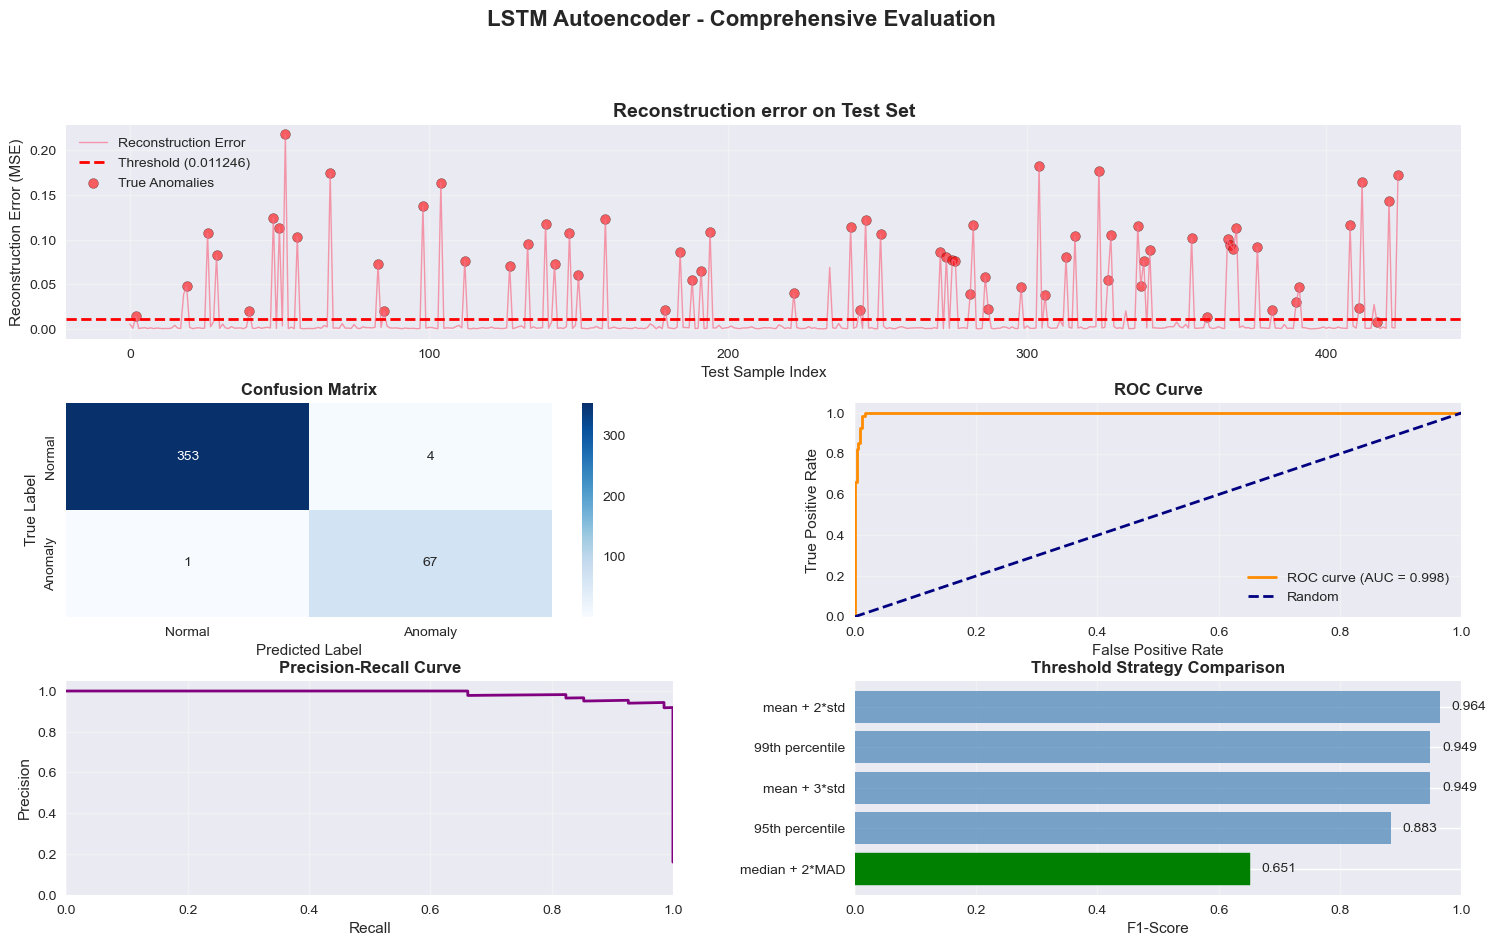

In [29]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
cm = confusion_matrix(y_test, y_pred_final)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(reconstruction_error, alpha=0.7, linewidth=1, label='Reconstruction Error')
ax1.axhline(y=best_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({best_threshold:.6f})')
ax1.scatter(np.where(y_test == 1)[0], reconstruction_error[y_test == 1],color='red', s=50, label='True Anomalies', alpha=0.6, edgecolors='black')
ax1.set_title('Reconstruction error on Test Set', fontsize=14, fontweight='bold')
ax1.set_xlabel('Test Sample Index')
ax1.set_ylabel('Reconstruction Error (MSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)
#Confusion Matrix
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=True,
            xticklabels=['Normal', 'Anomaly'],yticklabels=['Normal', 'Anomaly'])
ax2.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')
# 3. ROC Curve
ax3 = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(y_test, reconstruction_error)
roc_auc = auc(fpr, tpr)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)
#Precision-Recall Curve
ax4 = fig.add_subplot(gs[2, 0])
precision_curve, recall_curve, _ = precision_recall_curve(y_test, reconstruction_error)
ax4.plot(recall_curve, precision_curve, color='purple', lw=2)
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.grid(True, alpha=0.3)
#Threshold comparison
ax5 = fig.add_subplot(gs[2, 1])
threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.sort_values('f1', ascending=True)
y_pos = np.arange(len(threshold_df))
bars = ax5.barh(y_pos, threshold_df['f1'], color='steelblue', alpha=0.7)
best_idx = threshold_df['f1'].idxmax()
bars[best_idx].set_color('green')
bars[best_idx].set_alpha(1.0)
ax5.set_yticks(y_pos)
ax5.set_yticklabels(threshold_df['strategy'])
ax5.set_xlabel('F1-Score')
ax5.set_title('Threshold Strategy Comparison', fontsize=12, fontweight='bold')
ax5.set_xlim([0, 1])
ax5.grid(axis='x', alpha=0.3)
for i, v in enumerate(threshold_df['f1']):
    ax5.text(v + 0.02, i, f'{v:.3f}', va='center')
plt.suptitle('LSTM Autoencoder - Comprehensive Evaluation', fontsize=16, fontweight='bold', y=0.995)
plt.show()

### LSTM vs Isolation Forest vs Z-Score

In [32]:
# Calculate metrics for LSTM Autoencoder
lstm_precision = precision_score(y_test, y_pred_final, zero_division=0)
lstm_recall = recall_score(y_test, y_pred_final, zero_division=0)
lstm_f1 = f1_score(y_test, y_pred_final, zero_division=0)
model_comparison = pd.DataFrame({'Model': ['Z-Score (Residual)', 'Isolation Forest', 'LSTM Autoencoder'],
                                 'Precision': [0.5000, 0.8919, 0.9437], 
                                 'Recall': [1.0000, 0.9706, 0.9853],
                                 'F1-Score': [0.6667, 0.9296, 0.9640]})
print("MODEL COMPARISON on TEST set")
print(model_comparison.to_string(index=False))
best_model_idx = model_comparison['F1-Score'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_model_f1 = model_comparison.loc[best_model_idx, 'F1-Score']
print(f"Best Model: {best_model_name} with F1-Score of {best_model_f1:.4f}")

MODEL COMPARISON on TEST set
             Model  Precision  Recall  F1-Score
Z-Score (Residual)     0.5000  1.0000    0.6667
  Isolation Forest     0.8919  0.9706    0.9296
  LSTM Autoencoder     0.9437  0.9853    0.9640
Best Model: LSTM Autoencoder with F1-Score of 0.9640


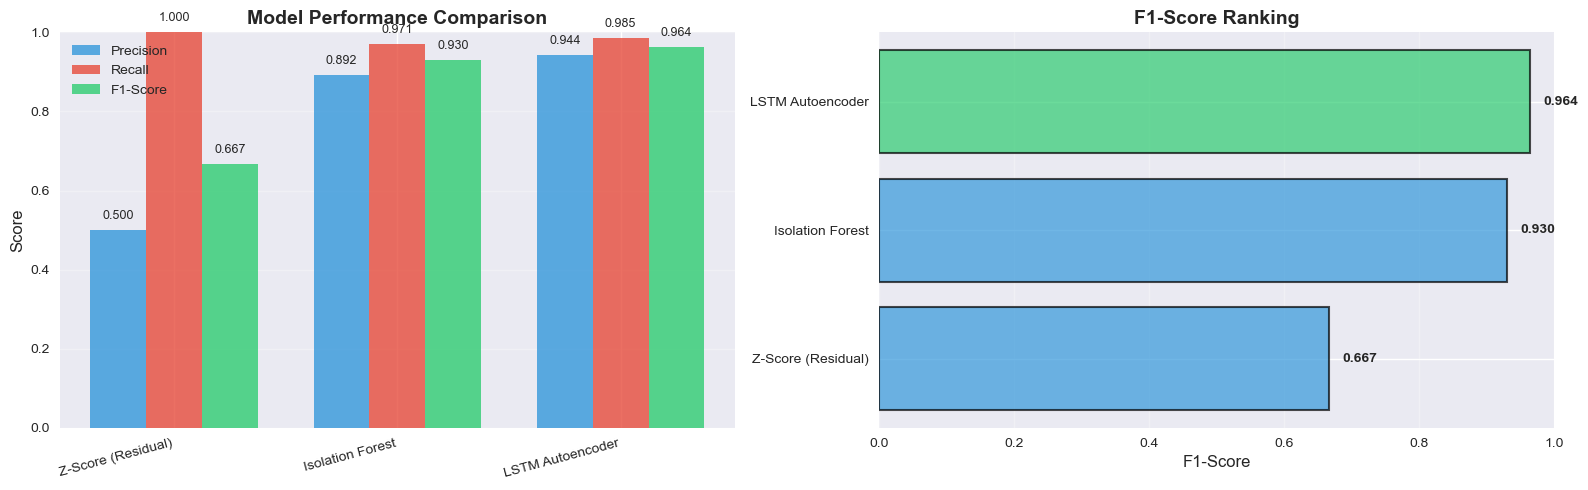

In [33]:
fig,axes = plt.subplots(1,2,figsize=(16,5))
ax1 = axes[0]
x = np.arange(len(model_comparison))
width = 0.25
bars1 = ax1.bar(x - width, model_comparison['Precision'], width,label='Precision', alpha=0.8, color='#3498db')
bars2 = ax1.bar(x, model_comparison['Recall'], width,label='Recall', alpha=0.8, color='#e74c3c')
bars3 = ax1.bar(x + width, model_comparison['F1-Score'], width,label='F1-Score', alpha=0.8, color='#2ecc71')
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_comparison['Model'], rotation=15, ha='right')
ax1.legend()
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
for i,(p,r,f) in enumerate(zip(model_comparison['Precision'],model_comparison['Recall'],model_comparison['F1-Score'])):
    ax1.text(i - width, p + 0.02, f'{p:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i, r + 0.02, f'{r:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width, f + 0.02, f'{f:.3f}', ha='center', va='bottom', fontsize=9)
ax2 = axes[1]
model_comparison_sorted = model_comparison.sort_values('F1-Score', ascending=True)
colors = ['#3498db' if m != best_model_name else '#2ecc71'
         for m in model_comparison_sorted['Model']]
bars = ax2.barh(range(len(model_comparison_sorted)),model_comparison_sorted['F1-Score'],color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(model_comparison_sorted)))
ax2.set_yticklabels(model_comparison_sorted['Model'])
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_title('F1-Score Ranking', fontsize=14, fontweight='bold')
ax2.set_xlim([0, 1])
ax2.grid(axis='x', alpha=0.3)
for i,(bar,val) in enumerate(zip(bars,model_comparison_sorted['F1-Score'])):
    ax2.text(val + 0.02, i, f'{val:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Save Model and Summary

In [40]:
import os
import joblib
BASE_DIR = r'C:\Users\owen\projects\time-series-anomaly-detection'
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR,exist_ok=True)
os.makedirs(RESULTS_DIR,exist_ok=True)
model_path = os.path.join(MODELS_DIR, 'lstm_autoencoder.keras')
model.save(model_path)
print(f"LSTM model saved to {model_path}")
scaler_path = os.path.join(MODELS_DIR, 'lstm_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")
results_df = pd.DataFrame({'reconstruction_error': reconstruction_error,
                           'is_anomaly': y_test,
                           'lstm_prediction': y_pred_final,
                           'threshold': best_threshold})
results_path = os.path.join(RESULTS_DIR, 'lstm_autoencoder_predictions.csv')
results_df.to_csv(results_path, index=False)
print(f"Predictions saved to {results_path}")
comparison_path = os.path.join(RESULTS_DIR, 'all_models_comparison.csv')
model_comparison.to_csv(comparison_path, index=False)
print(f"Model comparison saved to {comparison_path}")
threshold_path = os.path.join(RESULTS_DIR, 'lstm_threshold_comparison.csv')
pd.DataFrame(threshold_results).to_csv(threshold_path, index=False)
print(f"Threshold comparison saved to {threshold_path}")
final_df = pd.DataFrame(train_final.history)
final_path = os.path.join(RESULTS_DIR, 'lstm_training_history.csv')
final_df.to_csv(final_path, index=False)
print(f"Training history saved to {final_path}")
print("all saved done!")
print(f"\nResults location: {RESULTS_DIR}")
print(f"Models location: {MODELS_DIR}")

LSTM model saved to C:\Users\owen\projects\time-series-anomaly-detection\models\lstm_autoencoder.keras
Scaler saved to C:\Users\owen\projects\time-series-anomaly-detection\models\lstm_scaler.pkl
Predictions saved to C:\Users\owen\projects\time-series-anomaly-detection\results\lstm_autoencoder_predictions.csv
Model comparison saved to C:\Users\owen\projects\time-series-anomaly-detection\results\all_models_comparison.csv
Threshold comparison saved to C:\Users\owen\projects\time-series-anomaly-detection\results\lstm_threshold_comparison.csv
Training history saved to C:\Users\owen\projects\time-series-anomaly-detection\results\lstm_training_history.csv
all saved done!

Results location: C:\Users\owen\projects\time-series-anomaly-detection\results
Models location: C:\Users\owen\projects\time-series-anomaly-detection\models


# Summary and Comparison

Model Architecture:
- Encoder: LSTM(32) → BN → Dropout → LSTM(16) → BN → Dropout → LSTM(8)
- Decoder: LSTM(8) → BN → Dropout → LSTM(16) → BN → Dropout → LSTM(32)
- Input shape: (10, 4)
- Total parameters: 17,220
Training:
 - Epochs trained: 31
 - Final training loss: 0.007641
 - Final validation loss: 0.003008
 - Training samples: 830 (normal only)
Threshold Selection:
 - Strategy: mean + 2*std
 - Threshold: 0.011246
Test Set Performance:
 - Precision: 0.9437
 - Recall: 0.9853
 - F1-Score: 0.9640
 - ROC AUC: 0.9979

Comparison:
   1. Z-Score (Residual)        - F1: 0.6667
   2. Isolation Forest          - F1: 0.9296
   3. LSTM Autoencoder          - F1: 0.9640 - **WIN**

LSTM Autoencoder achieved excellent performance.
High recall of (98.53%) means catches most anomalies
High precision of (94.37%) means low false alarm rate
LSTM Autoencoder is the BEST performing model.